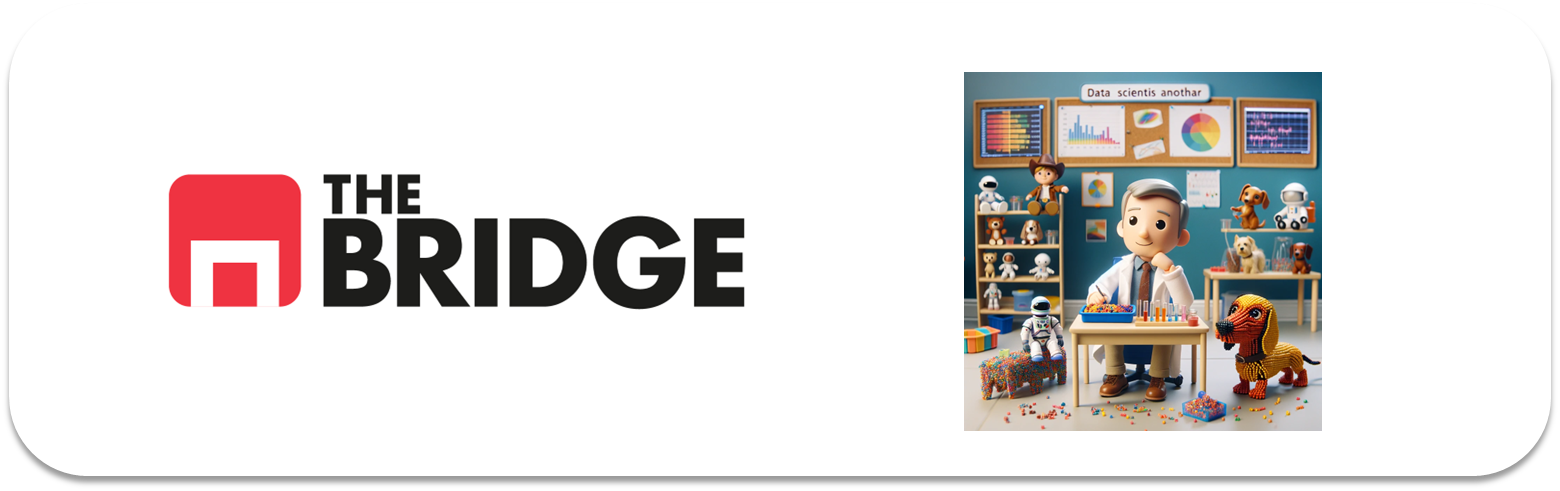

## PRACTICA OBLIGATORIA: ANÁLISIS UNIVARIANTE

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook. Te dejo una que vas a necesitar sí o sí

In [154]:

import seaborn as sns
import pandas as pd

from bootcampviztools import pinta_distribucion_categoricas, plot_combined_graphs




### #1 Preparación


### #1.1


Carga en un dataframe los datos del titanic a partir de un dataset de seaborn. Para ello:

* ejecuta ```python sns.get_dataset_names()```
* localiza el nombre que puede ser el adecuado para el ejercicio
* Asigna la salida de ```sns.load_dataset(<nombre_del_dataset>)``` a una variable "df_titanic"

In [155]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [156]:
df_titanic = sns.load_dataset("titanic")

### #1.2

Muestra una porción del dataset ("df_titanic") y su info general. ¿Hay nulos?

In [157]:
df_titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [158]:
df_titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [159]:
df_titanic.describe()['age']



count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

In [160]:
df_titanic['class'].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

In [161]:
df_titanic['who'].value_counts()

who
man      537
woman    271
child     83
Name: count, dtype: int64

In [162]:
df_titanic['embark_town'].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

### #1.3

Obtén el porcentaje de nulos y decide que hacer con las columnas con nulos y ejecútalo. Además deshazte de la columna "parch" que no la emplearemos.

In [163]:
df_titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [164]:
# La moda me daba una serie, hay que coger el primer valor para poder usarlo para sustituir
embarked_mode = df_titanic['embarked'].mode().iloc[0]
embarked_mode

'S'

In [165]:
embarkedtown_mode = df_titanic['embark_town'].mode().iloc[0]
embarkedtown_mode

'Southampton'

In [166]:
# Sistituyo los valores nulos por la moda (para cambiar poquito los datos)
df_titanic['embarked'] = df_titanic['embarked'].fillna(embarked_mode)

In [167]:
df_titanic['embark_town'] = df_titanic['embark_town'].fillna(embarkedtown_mode)

In [170]:
titanic_child = df_titanic.who == "child"

median_child = df_titanic.loc[titanic_child,"age"].median()

median_child
null_age = df_titanic.age.isnull()

df_titanic.loc[titanic_child & null_age, "age"] = median_child

In [ ]:
# Sistituyo las edades por la mediana para cambiar poco y mantener fiables

df_age_median = df_titanic['age'].median()

df_age_median

df_titanic['age'] = df_titanic['age'].fillna(df_age_median)

df_titanic['age'] 


np.float64(5.0)

In [173]:
df_titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64

In [174]:


deck_mode = df_titanic['deck'].mode().iloc[0]
deck_mode

'C'

In [175]:
df_titanic['deck'] = df_titanic['deck'].fillna(deck_mode)

In [176]:
# Comprobamos que no queda ningun valor nulo
df_titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

In [152]:
df_titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,C,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,C,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,C,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,C,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,C,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [177]:
df_titanic.drop(['parch'], axis=1, inplace= True)

In [178]:
df_titanic

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,7.2500,S,Third,man,True,C,Southampton,no,False
1,1,1,female,38.0,1,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,7.9250,S,Third,woman,False,C,Southampton,yes,True
3,1,1,female,35.0,1,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,8.0500,S,Third,man,True,C,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,13.0000,S,Second,man,True,C,Southampton,no,True
887,1,1,female,19.0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,28.0,1,23.4500,S,Third,woman,False,C,Southampton,no,False
889,1,1,male,26.0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


### #1.4
Sobre el dataset "limpio". Rellena la tabla de descripción (muy breve) de lo que es cada columna en función de su nombre y los valores. Para ayudarte:
* Se trata del dataset que reune lo más parecido a un manifiesto de supervivientes y fallecidos en el viaje.
* sibsp: Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros)
* embarked: Es la incial de la letra de la ciudad donde embarcó la persona.


| Columna/Variable | Descripción                                  |
| ---------------- | -------------------------------------------- |
| survived         | Indica si el pasajero sobrevivió al desastre |
| pclass           | Clase del billete del pasajero               |
| sex              | Sexo del pasajero                            |
| age              | Edad registrada del pasajero                 |
| sibsp            | Número de hermanos, cónyuge o pareja a bordo |
| parch            | Número de padres o hijos a bordo             |
| fare             | Precio pagado por el billete                 |
| embarked         | Puerto donde embarcó el pasajero             |
| class            | Clase del billete en formato textual         |
| who              | Categoría del pasajero según edad y sexo     |
| adult_male       | Indica si el pasajero era un hombre adulto   |
| deck             | Cubierta del barco asignada al pasajero      |
| embark_town      | Ciudad de embarque                           |
| alive            | Indica si el pasajero vivió o falleció       |
| alone            | Indica si viajaba solo                       |



### #1.5

Busca en internet las tres ciudades que visitó el Titanic antes de poner rumbo a su destino y llegar a alta mar. Cambia las iniciales por esos valores.

In [183]:
embarked_towns = {
    'S' : 'Southampton',
    'C' : 'Cherbourg',
    'Q' : 'Queenstown'
} 

In [184]:
df_titanic["embarked"] = df_titanic["embarked"].replace(embarked_towns)

In [186]:
df_titanic["embarked"] == df_titanic["embark_town"] 

0      True
1      True
2      True
3      True
4      True
       ... 
886    True
887    True
888    True
889    True
890    True
Length: 891, dtype: bool

### #2 Análisis

Sabiendo que el objetivo de nuestro análisis es hacer un estudio de la superviviencia y mortalidad en el viaje... Haz un análisis univariante completo y ordenado de las siguientes variables:
["survived","who","age","fare","class","embarked","alone"]
Nota: Si quieres añadir más, perfecto.

Separa el análisis en categóricas (incluyendo binarias) y numéricas. Muestra valores, gráficas y conclusiones/observaciones (2 o 3 por variable)

In [187]:
# Primero dividir las variables por tipo, usando la función que programamos en los ejercicios
def card_tipo(df,umbral_categoria = 10, umbral_continua = 30):
    # Primera parte: Preparo el dataset con cardinalidades, % variación cardinalidad, y tipos
    df_temp = pd.DataFrame([df.nunique(), df.nunique()/len(df) * 100, df.dtypes]) # Cardinaliad y porcentaje de variación de cardinalidad
    df_temp = df_temp.T # Como nos da los valores de las columnas en columnas, y quiero que estas sean filas, la traspongo
    df_temp = df_temp.rename(columns = {0: "Card", 1: "%_Card", 2: "Tipo"}) # Cambio el nombre de la transposición anterior para que tengan más sentido, y uso asignación en vez de inplace = True (esto es arbitrario para el tamaño de este dataset)

    # Corrección para cuando solo tengo un valor
    df_temp.loc[df_temp.Card == 1, "%_Card"] = 0.00

    # Creo la columna de sugerenica de tipo de variable, empiezo considerando todas categóricas pero podría haber empezado por cualquiera, siempre que adapte los filtros siguientes de forma correspondiente
    df_temp["tipo_sugerido"] = "Categorica"
    df_temp.loc[df_temp["Card"] == 2, "tipo_sugerido"] = "Binaria"
    df_temp.loc[df_temp["Card"] >= umbral_categoria, "tipo_sugerido"] = "Numerica discreta"
    df_temp.loc[df_temp["%_Card"] >= umbral_continua, "tipo_sugerido"] = "Numerica continua"
    # Ojo los filtros aplicados cumplen con el enunciado pero no siguen su orden y planteamiento

    return df_temp

In [188]:
card_tipo(df_titanic)

,Card,%_Card,Tipo,tipo_sugerido
survived,2,0.224467,int64,Binaria
pclass,3,0.3367,int64,Categorica
sex,2,0.224467,str,Binaria
age,88,9.876543,float64,Numerica discreta
sibsp,7,0.785634,int64,Categorica
fare,248,27.833895,float64,Numerica discreta
embarked,3,0.3367,str,Categorica
class,3,0.3367,category,Categorica
who,3,0.3367,str,Categorica
adult_male,2,0.224467,bool,Binaria


In [190]:
categoricas = ["alive","who","class","embarked","alone","sex"]
numericas = ["age","fare"]

### #2.1 Categóricas

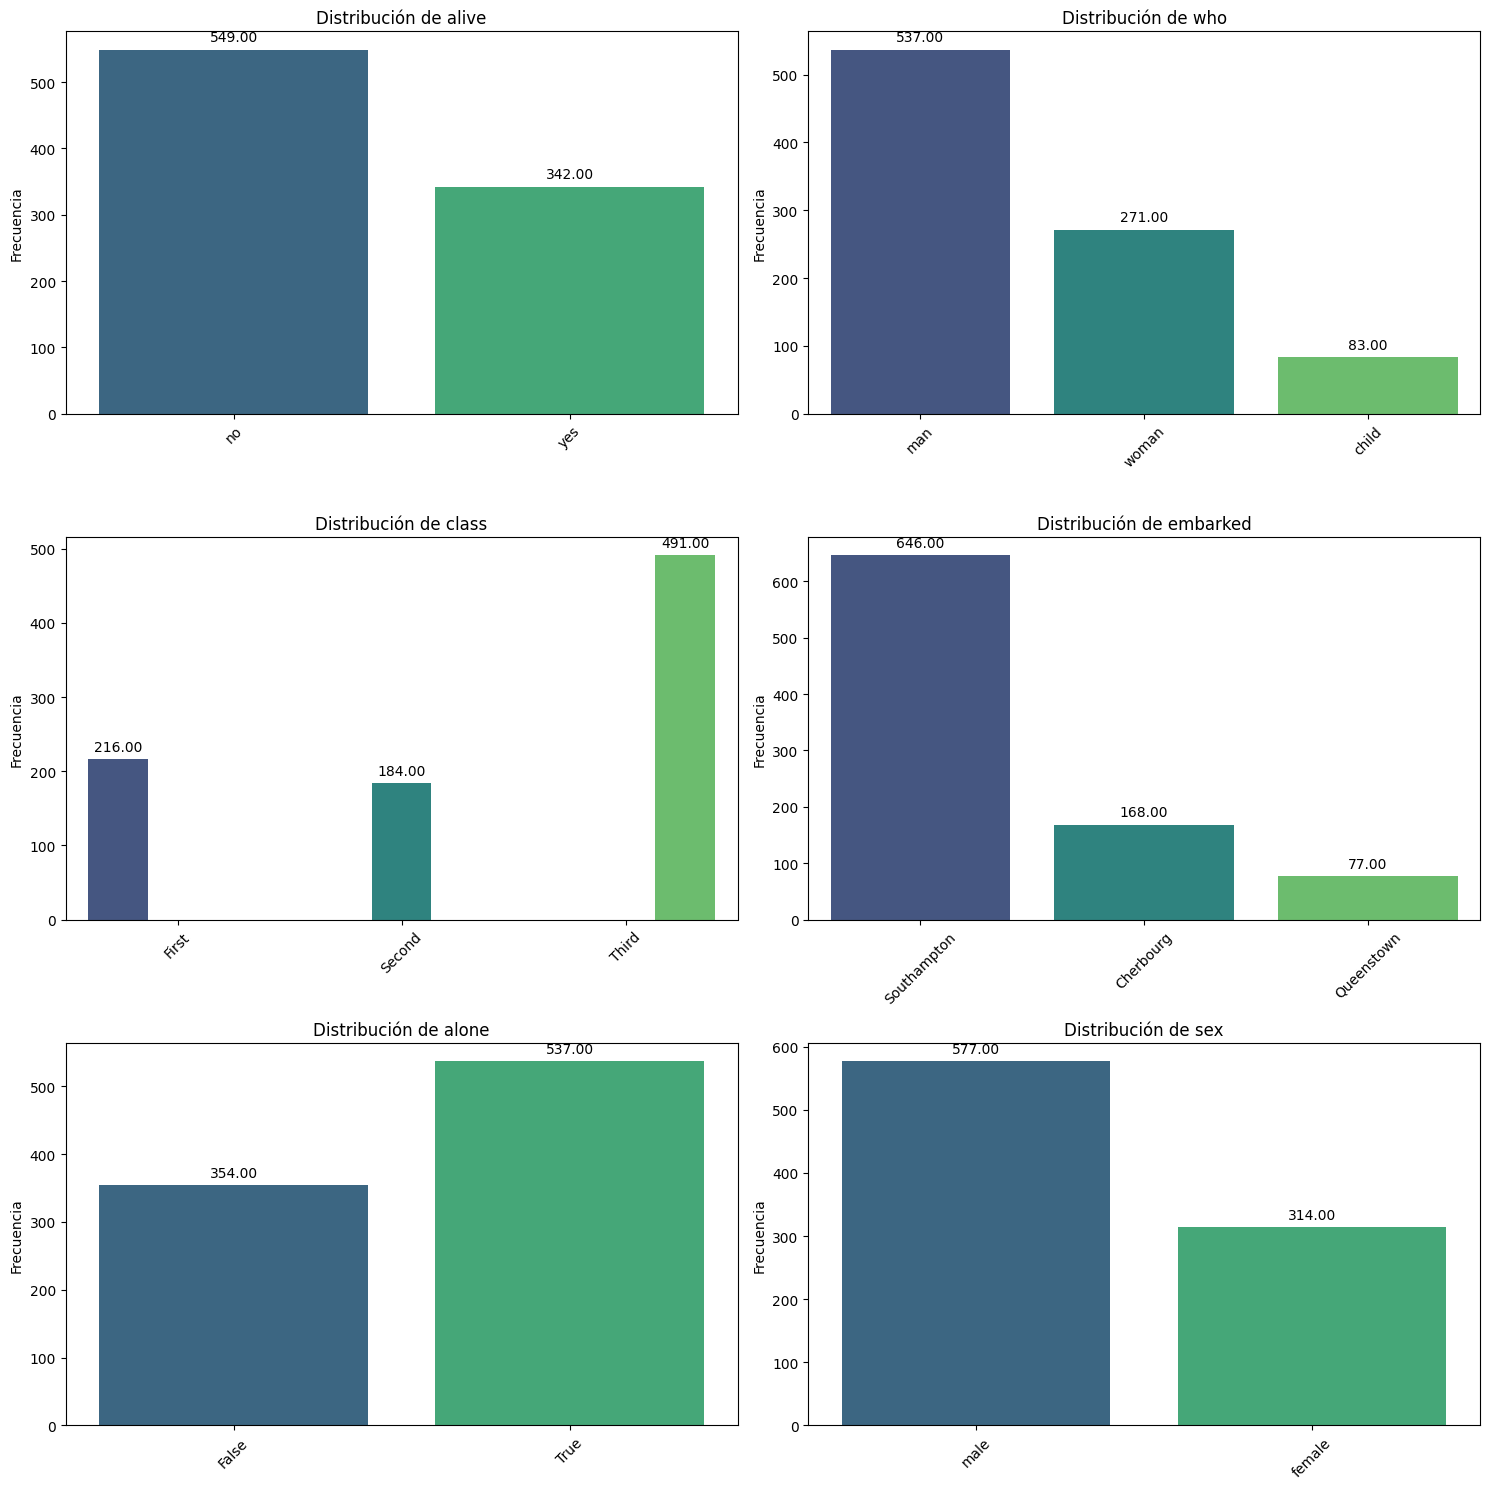

In [191]:
pinta_distribucion_categoricas(df_titanic, categoricas, mostrar_valores= True)

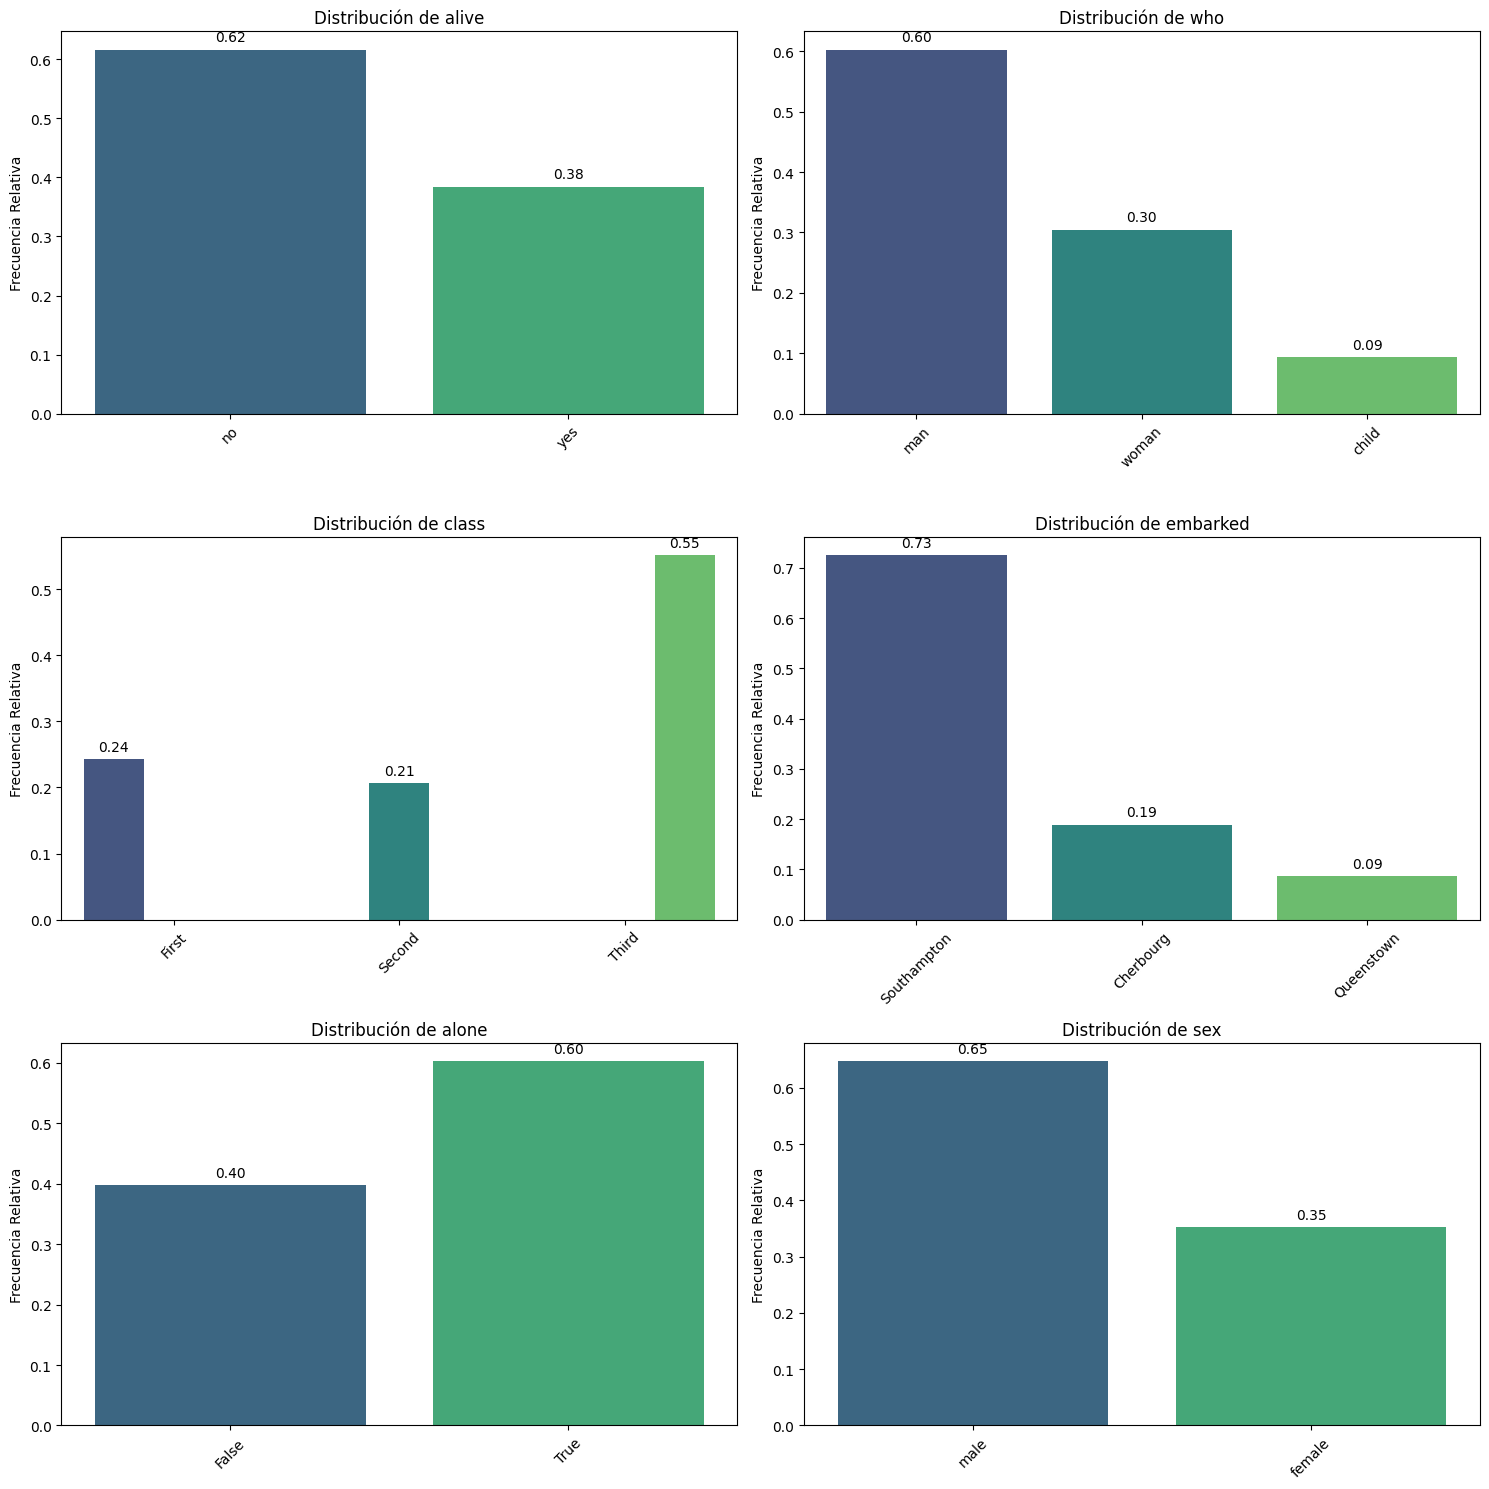

In [192]:
pinta_distribucion_categoricas(df_titanic, categoricas,relativa= True, mostrar_valores= True)

### #2.2 Numéricas

In [195]:
df_titanic[["age","fare"]].describe()

,age,fare
count,891.000000,891.000000
mean,29.361582,32.204208
std,13.019697,49.693429
min,0.420000,0.000000
25%,22.000000,7.910400
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


In [194]:
def get_CV(df, columna):
    columna = [columna] if type(columna) == str else columna
    return df[columna].describe().T["std"]/df[columna].describe().T["mean"] * 100

In [196]:
get_CV(df_titanic,"age")

age    44.342625
dtype: float64

In [197]:
get_CV(df_titanic,"fare")

fare    154.307253
dtype: float64

(2, 2)


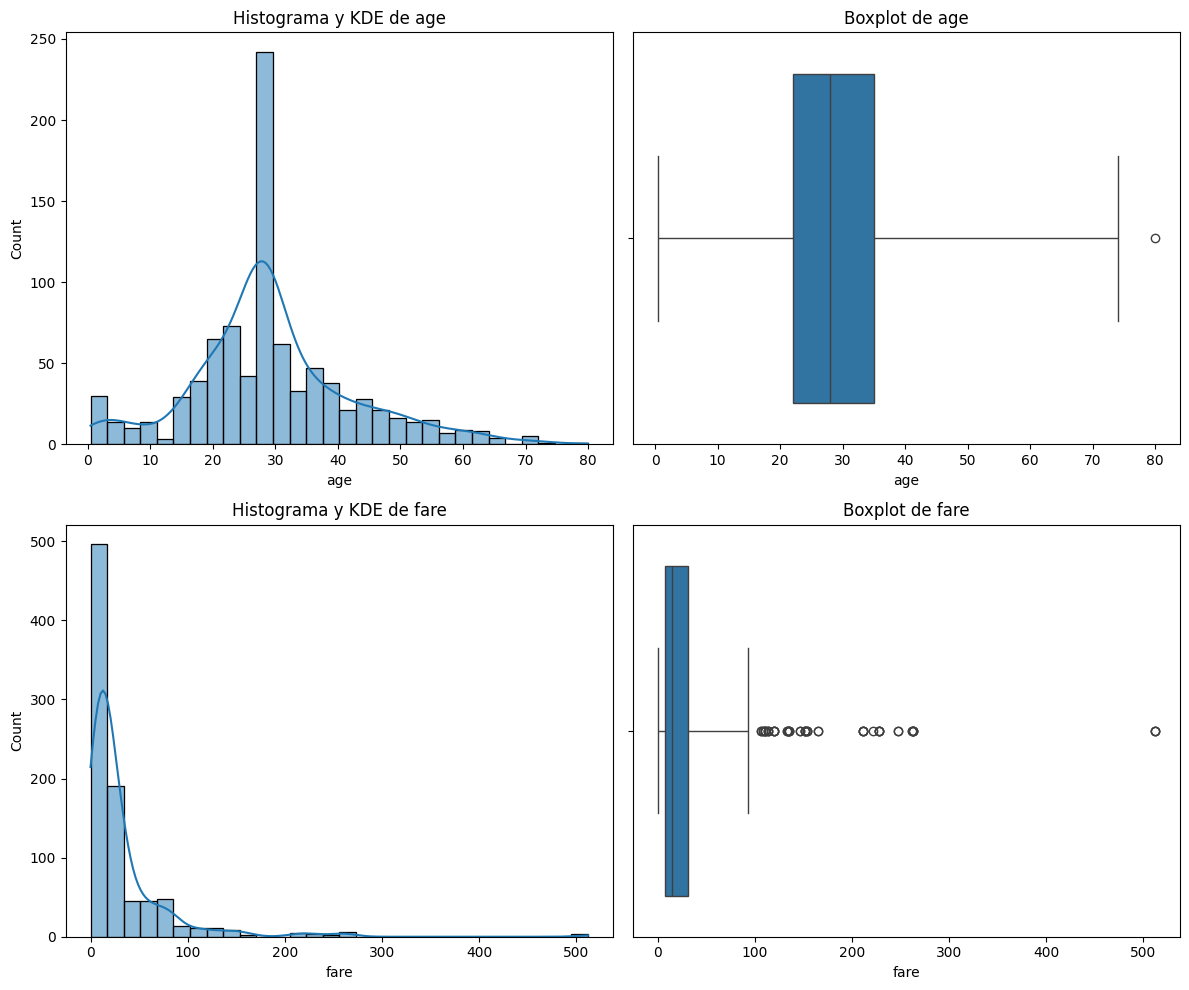

In [207]:
plot_combined_graphs(df_titanic, ["age","fare"], whisker_width=3, bins = 30)

In [ ]:
# Pendiente de hacer análisis escrito de los resultados.